# The goal of this notebook is to perform an interpretability analysis of a trained OAMFA model

This should mainly test if \mu and \Psi maps to physical phenomenoms, preferably the tru spectral signature of a material, and sensor noise.

#### **Data**
Two images: 
1) one that contains two clear materials (Ocean + Land) HYPSO-1_HSI_20250515T104003Z-l1a.nc <- From sula, allso conatins snow-pixels
2) one that contains (Ocean + Alge Ocean + Land) HYPSO-1_HSI_20250611T103127Z-l1a.nc <- Algebloom in skagerrak

Training-set: The whole images.\
Test-set: One pixel from each of the distinct biases (water, land, alge water).\

#### **Tests**
1) **Extracted \mu**
- Train the model on the image by streaming it
- Extract mu from each component after training 
- Sample one pixel that represents each of the distinct biases 
- Compare \mu to the pixel, both by pplotting and by calculating SAM

2) **Noise \Psi**
- Plot \Psi after training on a normal image
- Inject noise to specific bands in an image
- stream the image, and plot the resulting \Psi
- Preferably, there is a spike in \Psi on the same band as where the noise was injected

3) **Covariance \Lambda**
- The goal should be to identify if \Lambda is capturing any specific inner ariance in a given class. I am uncertain how to test this.





In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from utils import get_rgb, calculate_rmse, calculate_sam, reconstruct_mfa
import copy
import time
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize


parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from otfp import MFA_OTFP
from hypso import Hypso


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L2_NORMALIZATION = True  # Set to True to enable L2 normalization, False to disable

Loading baseline hypercube from ../data/interpretability_analysis/sula_2025-05-15T10-40-03Z-l1b.nc...
Successfully loaded | Shape: (598, 1092, 120)
Training Lines:  40 -> Shape: (598, 40, 120)
Testing Lines:   598 -> Shape: (598, 1052, 120)


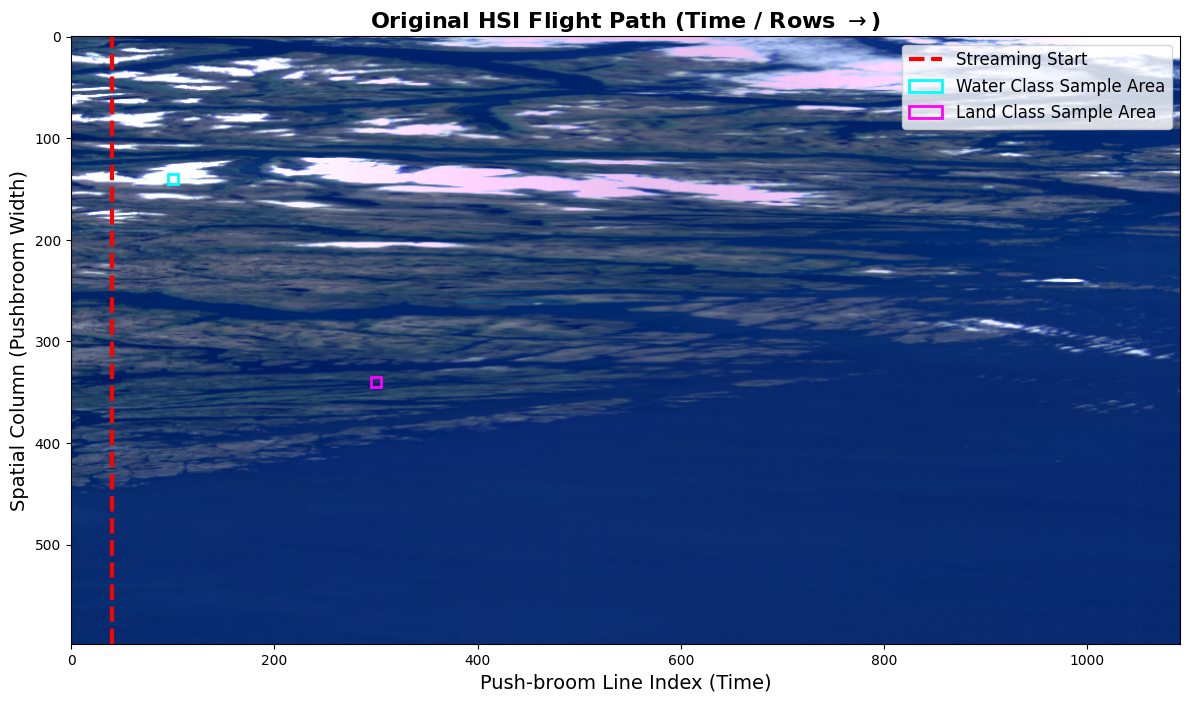

In [26]:
import sys
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from hypso import Hypso # Assuming this is imported

# 0. FILE PATHS & CONFIG
# nontrivial_classes_image_path = "../data/interpretability_analysis/skagerrak_bloom_2025-06-11T10-31-27Z-l1b.nc" 
trivial_classes_image_path = "../data/interpretability_analysis/sula_2025-05-15T10-40-03Z-l1b.nc" 

N_TRAIN_LINES = 40

# 1. LOAD DATA 
print(f"Loading baseline hypercube from {trivial_classes_image_path}...")
try:
    satobj = Hypso(trivial_classes_image_path)
    cube = getattr(satobj, "l1b_cube", None)
    if cube is None:
        raise ValueError("Missing 'l1b_cube' data.")
    img_full = cube.values.astype(np.float32)
    print(f"Successfully loaded | Shape: {img_full.shape}")
except Exception as e:
    print(f"FATAL: Error processing {trivial_classes_image_path}: {e}")
    sys.exit()

# 2. SPLIT DATA 
trivial_img_train = img_full[:, :N_TRAIN_LINES, :].copy()
trivial_img_test = img_full[:, N_TRAIN_LINES:, :].copy()
total_test_rows = trivial_img_test.shape[0]

print(f"Training Lines:  {N_TRAIN_LINES} -> Shape: {trivial_img_train.shape}")
print(f"Testing Lines:   {total_test_rows} -> Shape: {trivial_img_test.shape}")

# 3. SAMPLE PIXELS FOR INTERPRETABILITY 
AVERAGE_WINDOW = 5  # Number of rows to average for a smoother spectrum

# NOTE: These coordinates are (Row, Col) relative to the TEST set.
# If they are pointing to the wrong material in the plot below, adjust them!
single_water_pixel_coord = (100, 100)  
water_pixel_spectrum = trivial_img_test[single_water_pixel_coord[0], single_water_pixel_coord[1], :]
average_water_pixel_spectrum = np.mean(
    trivial_img_test[single_water_pixel_coord[0]:single_water_pixel_coord[0]+AVERAGE_WINDOW, 
                     single_water_pixel_coord[1], :], axis=0
)

land_pixel_coord = (300, 300)  
land_pixel_spectrum = trivial_img_test[land_pixel_coord[0], land_pixel_coord[1], :]
average_land_pixel_spectrum = np.mean(
    trivial_img_test[land_pixel_coord[0]:land_pixel_coord[0]+AVERAGE_WINDOW, 
                     land_pixel_coord[1], :], axis=0
)

# 4. PLOTTING THE SETUP
# A vertical figure to accommodate the flight path 
fig, axes = plt.subplots(1, 1, figsize=(12, 14)) 

# Assuming get_rgb() is defined in your notebook and extracts the RGB bands
axes.imshow(get_rgb(img_full))

axes.set_title("Original HSI Flight Path (Time / Rows $\\rightarrow$)", fontsize=16, fontweight='bold')
# Plot a line that marks the 40 training samples
axes.axvline(x=N_TRAIN_LINES, color='red', linestyle='--', linewidth=3, label="Streaming Start")

# Update labels to match the natural orientation
axes.set_xlabel("Push-broom Line Index (Time)", fontsize=14)
axes.set_ylabel("Spatial Column (Pushbroom Width)", fontsize=14)

# Helper to place markers on the Natural image 
def add_pixel_marker(ax, coord, color, label):
    # coord is (row, col) in the test set. 
    # In matplotlib, x is the column width, y is the row height.
    x_pos = coord[1] - 5
    y_pos = coord[0] + N_TRAIN_LINES - 5
    
    rect = mpatches.Rectangle((x_pos, y_pos), 10, 10, 
                              linewidth=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)

add_pixel_marker(axes, single_water_pixel_coord, 'cyan', 'Water Class Sample Area')
add_pixel_marker(axes, land_pixel_coord, 'magenta', 'Land Class Sample Area')
axes.legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()

# Clean up memory
del satobj, cube, img_full, trivial_img_train, trivial_img_test

## Training the model

In [ ]:
# Your original code:
img_train = trivial_img_train.reshape(-1, trivial_img_train.shape[-1])  # Flatten to (num_pixels, num_bands)
img_train = torch.from_numpy(img_train).float().to(device)  # Convert to PyTorch tensor

MFA_OTFP_model=MFA_OTFP(
    n_channels=120, 
    device="cpu", 
    outlier_update_treshold=1000,
    q_max=5,
    L2_normalization=L2_NORMALIZATION
)

MFA_OTFP_model.fit(img_train)

## Streaming The system